In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. IMPORT REQUIRED LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression

# Regression Models
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

# XGBoost
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


file_path = "/content/sports_performance_data.csv"

df = pd.read_csv(file_path)
print(df.head())

  Athlete_ID Athlete_Name Sport_Type          Event  Training_Hours_per_Week  \
0       A754   Athlete_15    Running  50m Freestyle                    18.11   
1       A792   Athlete_95     Soccer            NaN                    12.43   
2       A195   Athlete_28   Swimming    100m Sprint                    11.99   
3       A559   Athlete_76    Cycling    100m Sprint                    20.41   
4       A384   Athlete_20   Swimming  50m Freestyle                    37.88   

   Average_Heart_Rate   BMI  Sleep_Hours_per_Night  Daily_Caloric_Intake  \
0               192.6  29.6                    7.6                1890.0   
1                77.3  18.7                    NaN                2811.9   
2               127.1  26.8                    NaN                3018.9   
3                68.3  24.9                    4.2                3773.3   
4               184.2  27.0                    9.5                1721.2   

   Hydration_Level  ... Previous_Competition_Performance  Trai

**2. DATA DESCRIPTION & COLLECTION**

In [ ]:
# Load dataset from CSV file
df = pd.read_csv("sports_performance_data.csv")

# Display first 5 rows to get a glimpse of the data
print("\nFirst 5 rows of dataset:")
print(df.head())

# Display dataset info: column types, non-null counts
print("\nDataset Information:")
print(df.info())

# Shows how many missing values exist in each column
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

# Summary statistics (mean, median, min/max) for numerical columns
print("\n--- STATISTICAL SUMMARY ---")
print(df.describe())



First 5 rows of dataset:
  Athlete_ID Athlete_Name Sport_Type          Event  Training_Hours_per_Week  \
0       A754   Athlete_15    Running  50m Freestyle                    18.11   
1       A792   Athlete_95     Soccer            NaN                    12.43   
2       A195   Athlete_28   Swimming    100m Sprint                    11.99   
3       A559   Athlete_76    Cycling    100m Sprint                    20.41   
4       A384   Athlete_20   Swimming  50m Freestyle                    37.88   

   Average_Heart_Rate   BMI  Sleep_Hours_per_Night  Daily_Caloric_Intake  \
0               192.6  29.6                    7.6                1890.0   
1                77.3  18.7                    NaN                2811.9   
2               127.1  26.8                    NaN                3018.9   
3                68.3  24.9                    4.2                3773.3   
4               184.2  27.0                    9.5                1721.2   

   Hydration_Level  ... Previous_Com

**3. DATA PREPROCESSING – CLEANING**

In [ ]:
# Separate numerical and categorical columns

num_cols = df.select_dtypes(include=['int64','float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

 3.1 HANDLE MISSING VALUES

In [ ]:
#  DISPLAY MISSING VALUES
# -----------------------------

print("\nMissing values before cleaning:")
print(df.isnull().sum())





Missing values before cleaning:
Athlete_ID                           633
Athlete_Name                         629
Sport_Type                           629
Event                                638
Training_Hours_per_Week              630
Average_Heart_Rate                   630
BMI                                  629
Sleep_Hours_per_Night                624
Daily_Caloric_Intake                 642
Hydration_Level                      637
Injury_History                      4716
Previous_Competition_Performance     630
Training_Intensity                   645
Resting_Heart_Rate                   631
Body_Fat_Percentage                  632
VO2_Max                              633
Event_Distance                       635
Altitude_Training                   3628
Mental_Focus_Level                   628
Competition_Date                     627
Performance_Metric                   618
dtype: int64


In [ ]:
# HANDLE MISSING VALUES

# - Numerical columns: replace missing values with median (less sensitive to outliers)
# - Categorical columns: replace missing values with mode (most frequent value)

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Athlete_ID                          0
Athlete_Name                        0
Sport_Type                          0
Event                               0
Training_Hours_per_Week             0
Average_Heart_Rate                  0
BMI                                 0
Sleep_Hours_per_Night               0
Daily_Caloric_Intake                0
Hydration_Level                     0
Injury_History                      0
Previous_Competition_Performance    0
Training_Intensity                  0
Resting_Heart_Rate                  0
Body_Fat_Percentage                 0
VO2_Max                             0
Event_Distance                      0
Altitude_Training                   0
Mental_Focus_Level                  0
Competition_Date                    0
Performance_Metric                  0
dtype: int64


3.2 OUTLIER TREATMENT USING IQR METHOD


In [ ]:
#DETECT OUTLIERS

# Using IQR (Interquartile Range) method
# Outliers can distort regression models; we need to visualize and remove them

def detect_outliers(col):
    """Detect outliers using IQR method"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected")
    return outliers

print("\nDetecting outliers for numerical columns:")
for col in num_cols:
    detect_outliers(col)



Detecting outliers for numerical columns:
Training_Hours_per_Week: 0 outliers detected
Average_Heart_Rate: 0 outliers detected
BMI: 0 outliers detected
Sleep_Hours_per_Night: 0 outliers detected
Daily_Caloric_Intake: 0 outliers detected
Hydration_Level: 0 outliers detected
Previous_Competition_Performance: 0 outliers detected
Resting_Heart_Rate: 0 outliers detected
Body_Fat_Percentage: 0 outliers detected
VO2_Max: 0 outliers detected
Event_Distance: 0 outliers detected
Mental_Focus_Level: 0 outliers detected
Performance_Metric: 0 outliers detected


In [ ]:
#REMOVE OUTLIERS

def remove_outliers(col):
    """Remove rows with outliers using IQR method"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

print("\nRemoving outliers from numerical columns...")
for col in num_cols:
    df = remove_outliers(col)


Removing outliers from numerical columns...


3.3 FIX SKEWED NUMERICAL FEATURES

In [ ]:
#DISPLAY

# Skewed numerical features can affect regression performance

print("\nSkewness of numerical columns before log transformation:")
print(df[num_cols].skew())


Skewness of numerical columns before log transformation:
Training_Hours_per_Week            -0.019063
Average_Heart_Rate                 -0.013563
BMI                                -0.005138
Sleep_Hours_per_Night               0.013271
Daily_Caloric_Intake               -0.017869
Hydration_Level                    -0.018864
Previous_Competition_Performance   -0.008808
Resting_Heart_Rate                 -0.005598
Body_Fat_Percentage                 0.021553
VO2_Max                            -0.002401
Event_Distance                      0.001901
Mental_Focus_Level                  0.011930
Performance_Metric                  0.004588
dtype: float64


In [ ]:
# FIX SKEWNESS

# Apply log1p (log(x+1)) transformation to highly skewed features (|skew|>1)
for col in num_cols:
    if abs(df[col].skew()) > 1:
        df[col] = np.log1p(df[col])

print("\nSkewness after log transformation:")
print(df[num_cols].skew())



Skewness after log transformation:
Training_Hours_per_Week            -0.019063
Average_Heart_Rate                 -0.013563
BMI                                -0.005138
Sleep_Hours_per_Night               0.013271
Daily_Caloric_Intake               -0.017869
Hydration_Level                    -0.018864
Previous_Competition_Performance   -0.008808
Resting_Heart_Rate                 -0.005598
Body_Fat_Percentage                 0.021553
VO2_Max                            -0.002401
Event_Distance                      0.001901
Mental_Focus_Level                  0.011930
Performance_Metric                  0.004588
dtype: float64


**4. EXPLORATORY DATA ANALYSIS (EDA)**

4.1 HISTOGRAMS

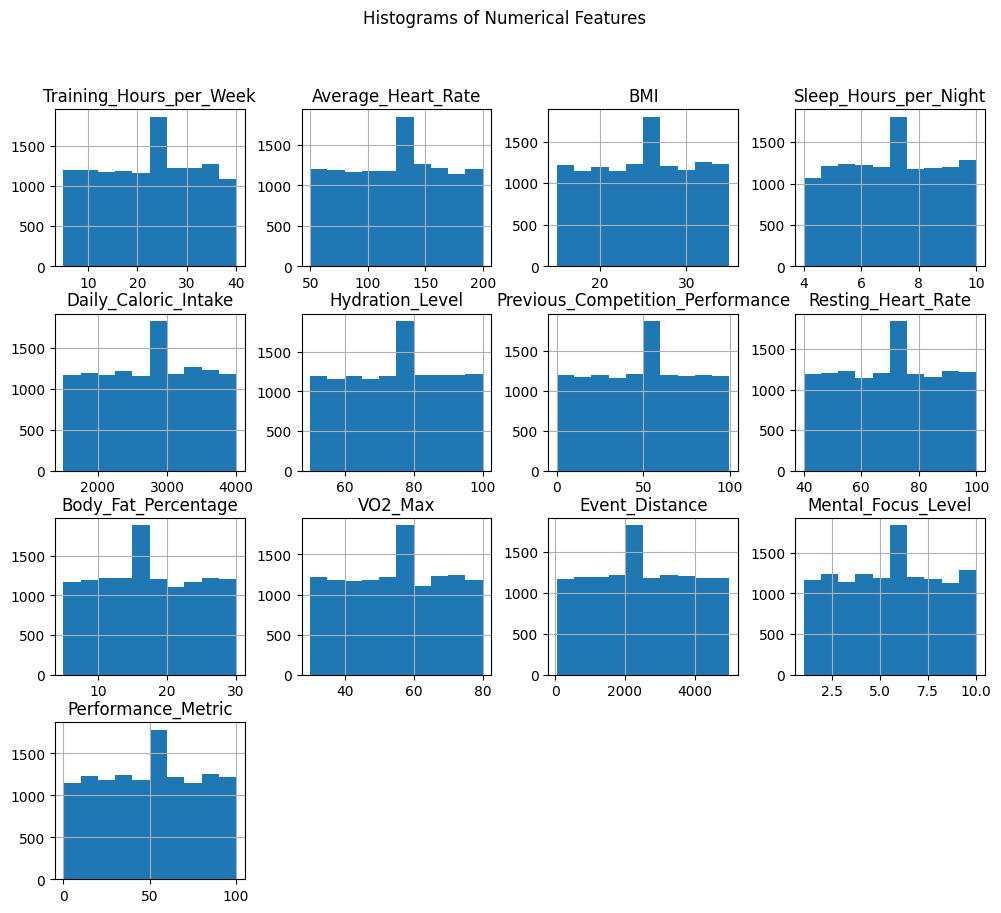

In [ ]:
# HISTOGRAMS → Understand distribution of numerical variables

df[num_cols].hist(figsize=(12,10))
plt.suptitle("Histograms of Numerical Features")
plt.show()


4.2 BOXPLOTS

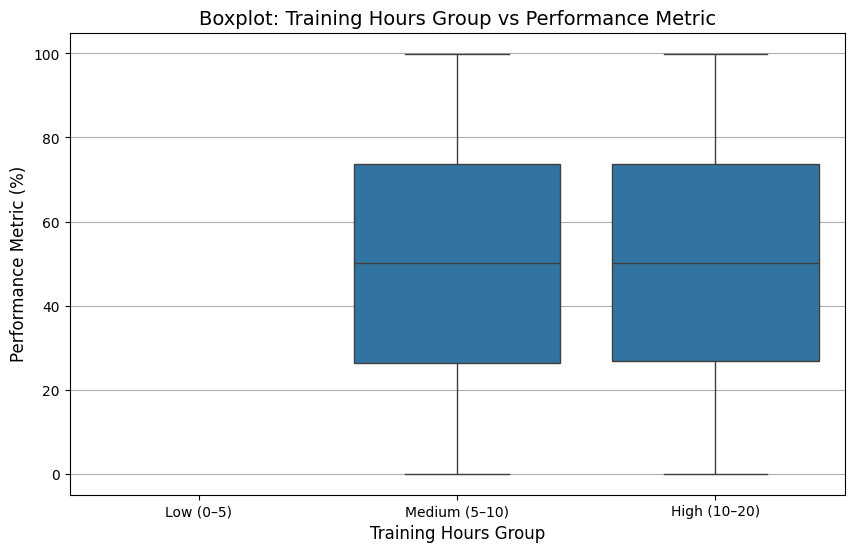

In [ ]:
# Boxplot: Training Hours per Week (Binned) vs Performance Metric
# -----------------------------------------------------------

# Step 1: Create bins (categorical groups) from Training Hours
df['Training_Hours_Group'] = pd.cut(
    df['Training_Hours_per_Week'],
    bins=[0, 5, 10, 20],   # Customize based on dataset distribution
    labels=['Low (0–5)', 'Medium (5–10)', 'High (10–20)']
)

# Step 2: Create the box plot
plt.figure(figsize=(10,6))

# Boxplot shows how Performance Metric varies across training hour categories
sns.boxplot(
    x=df['Training_Hours_Group'],
    y=df['Performance_Metric']
)

# Titles and labels
plt.title("Boxplot: Training Hours Group vs Performance Metric", fontsize=14)
plt.xlabel("Training Hours Group", fontsize=12)
plt.ylabel("Performance Metric (%)", fontsize=12)

plt.grid(axis='y')
plt.show()

4.3 CORRELATION HEATMAP

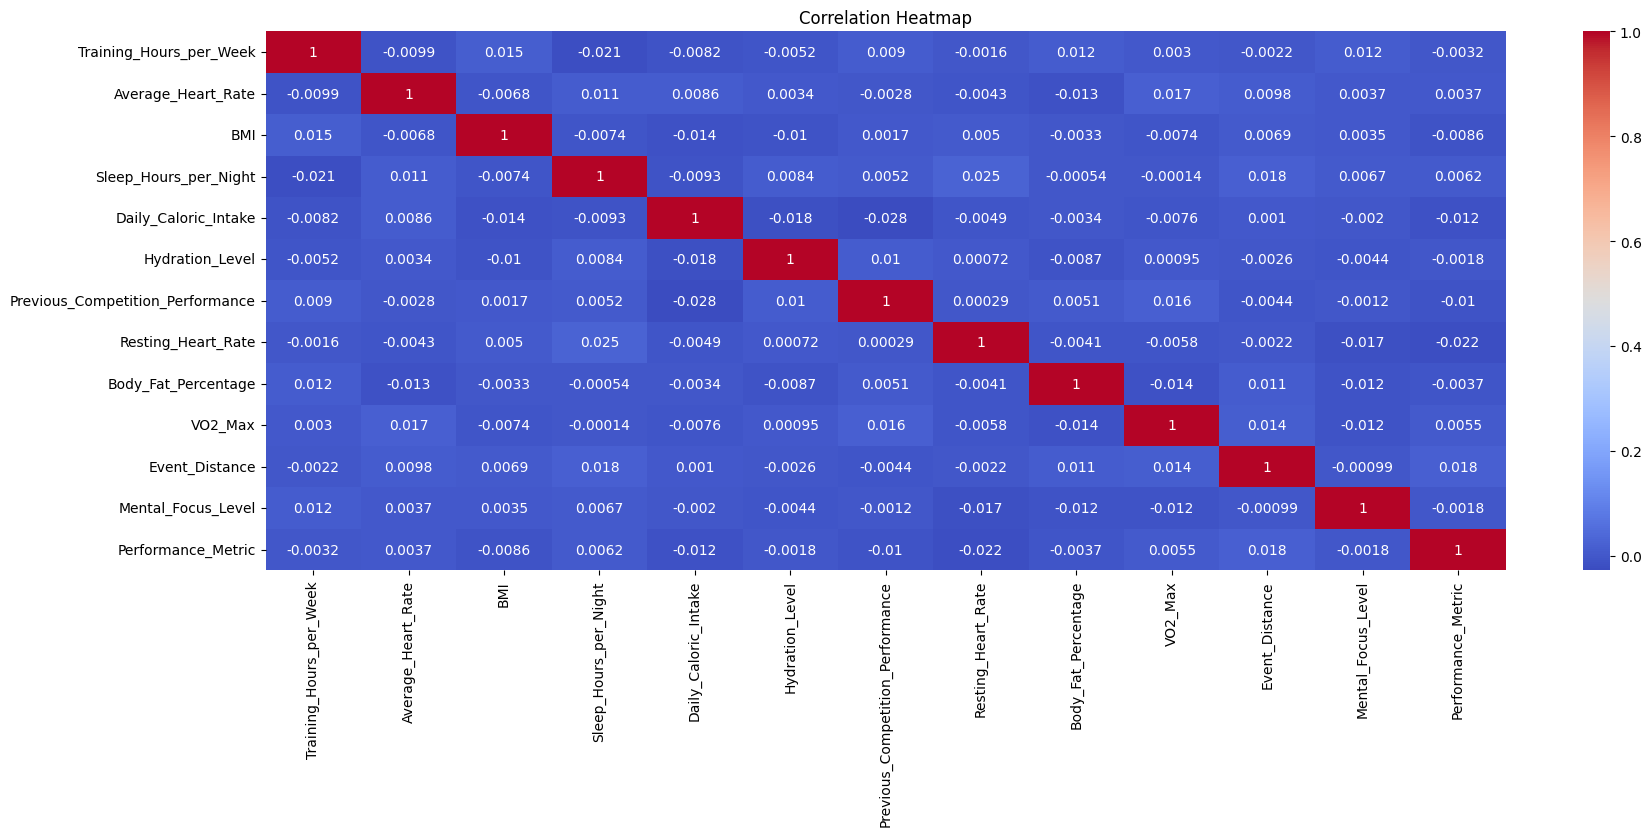

In [ ]:
# CORRELATION HEATMAP → Identify feature relationships

plt.figure(figsize=(20,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

4.4 Scatter Plot

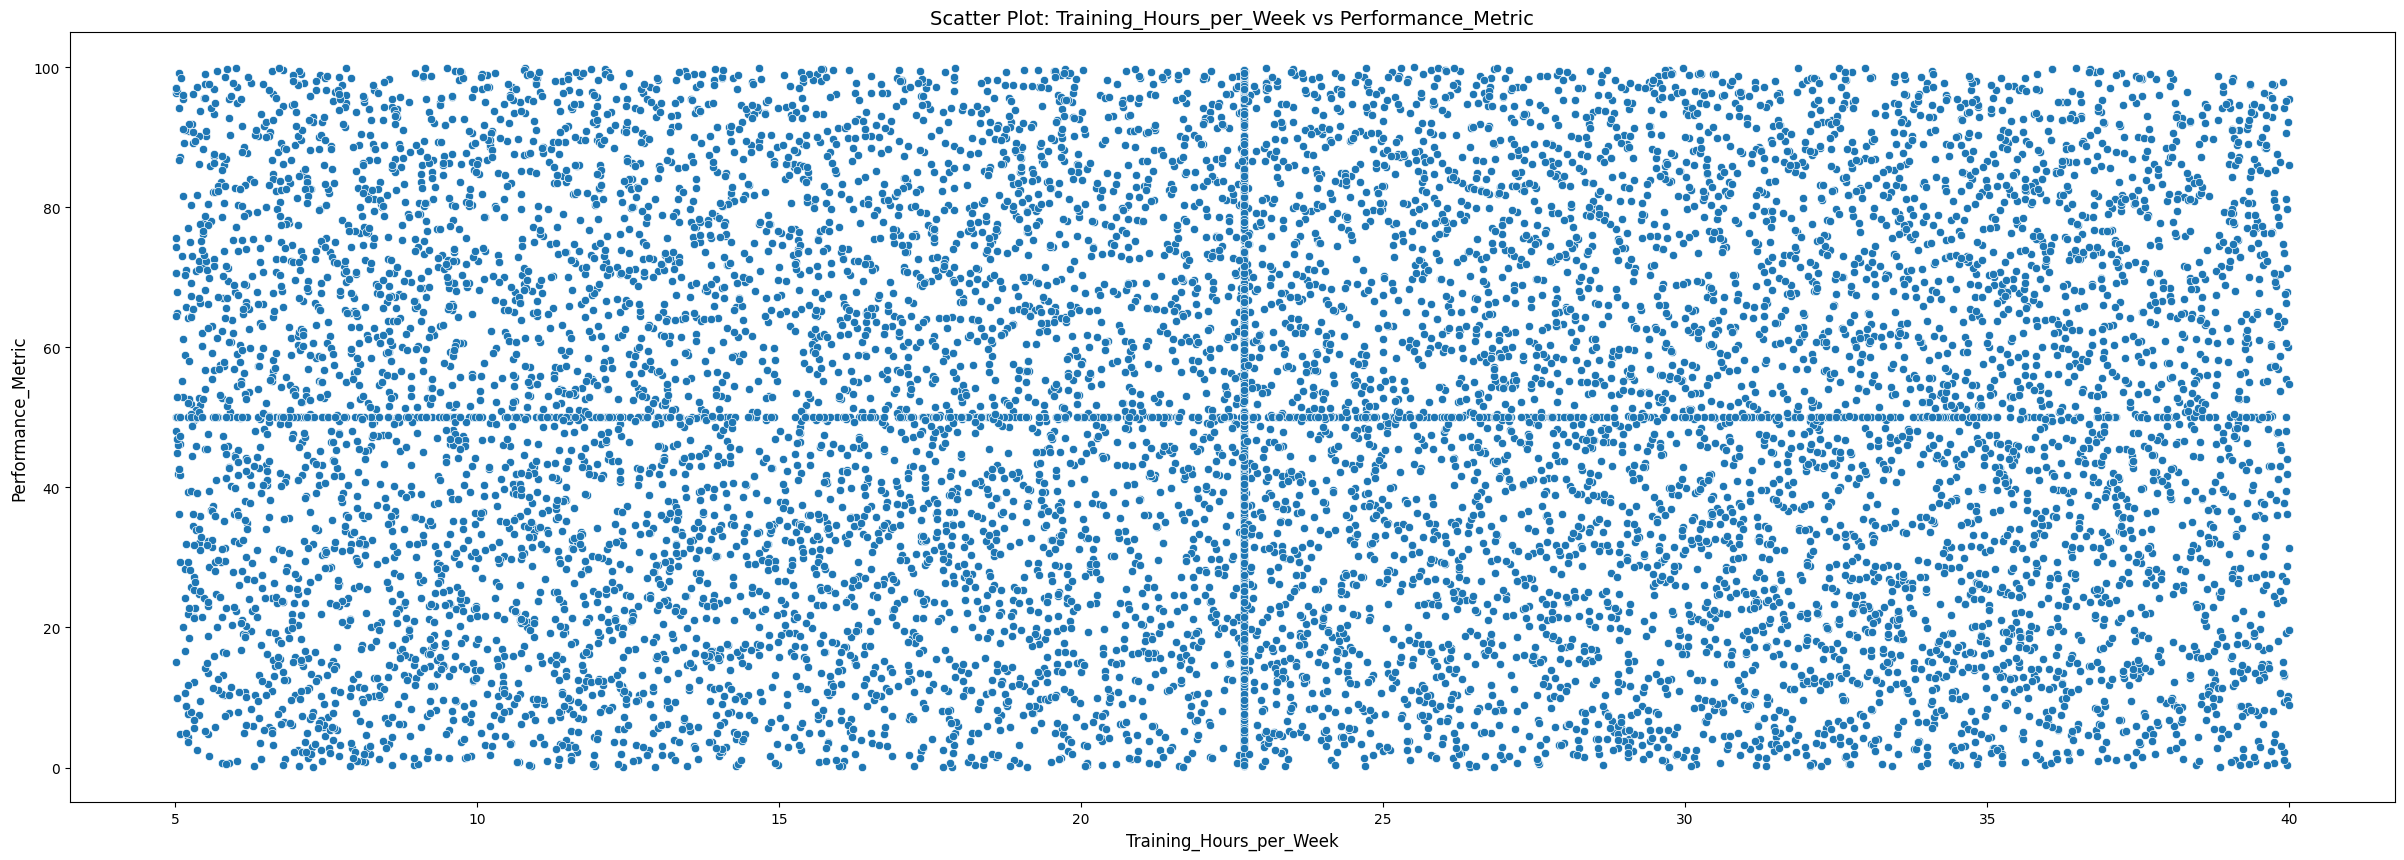

In [ ]:
# the target variable (Performance_Metric).

plt.figure(figsize=(30,10))   # Set figure size for better clarity

# Replace 'Feature1' with the numerical feature you want to compare
sns.scatterplot(
    data=df,               # Data source
    x='Training_Hours_per_Week',          # Independent variable (X-axis)
    y='Performance_Metric' # Target variable (Y-axis)
)

# Adding title and axis labels improves readability
plt.title("Scatter Plot: Training_Hours_per_Week vs Performance_Metric", fontsize=14)
plt.xlabel("Training_Hours_per_Week", fontsize=12)
plt.ylabel("Performance_Metric", fontsize=12)

plt.show()

4.5 KDE Plot

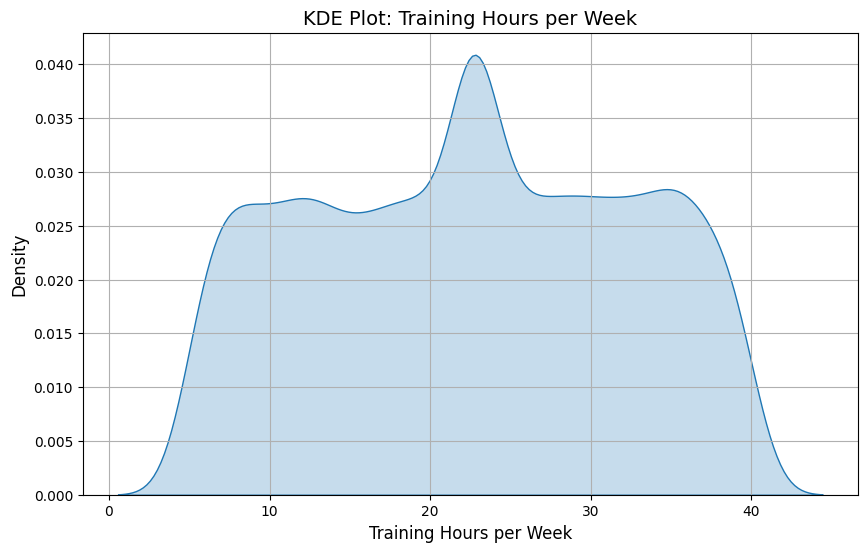

In [ ]:
# -----------------------------------------------------------
# KDE Plot for Training Hours per Week
# -----------------------------------------------------------

plt.figure(figsize=(10,6))

# KDE gives a smoothed curve over the histogram distribution
sns.kdeplot(df['Training_Hours_per_Week'], shade=True)

plt.title("KDE Plot: Training Hours per Week", fontsize=14)
plt.xlabel("Training Hours per Week", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True)
plt.show()


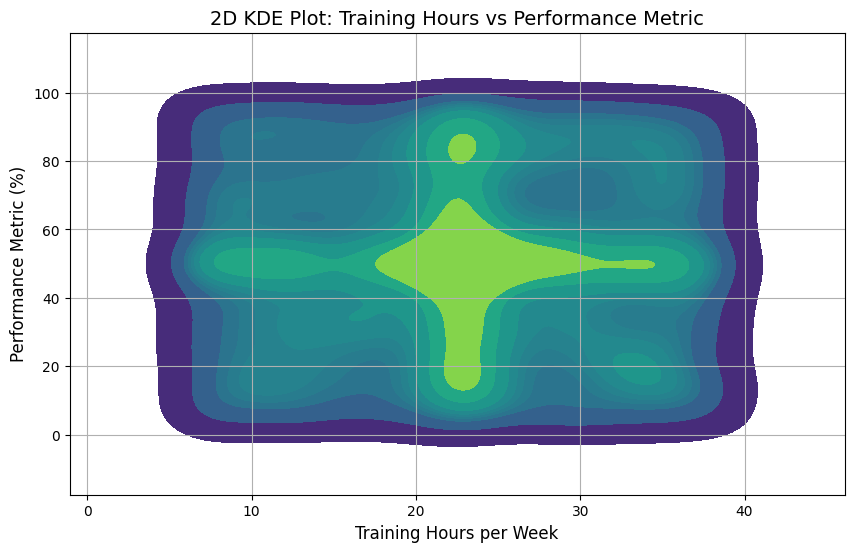

In [ ]:
# -----------------------------------------------------------
# Joint KDE Plot: Training Hours vs Performance Metric
# -----------------------------------------------------------

plt.figure(figsize=(10,6))

# 2D KDE shows density of points in a smoothed contour map
sns.kdeplot(
    x=df['Training_Hours_per_Week'],
    y=df['Performance_Metric'],
    fill=True,   # Filled contour plot
    cmap="viridis"  # Color map (you can change if needed)
)

plt.title("2D KDE Plot: Training Hours vs Performance Metric", fontsize=14)
plt.xlabel("Training Hours per Week", fontsize=12)
plt.ylabel("Performance Metric (%)", fontsize=12)
plt.grid(True)
plt.show()


**5. FEATURE ENGINEERING**

In [ ]:

# Encode categorical variables using LabelEncoder for regression models

print("Encoding categorical features using LabelEncoder...")
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Encoding categorical features using LabelEncoder...


**6. FEATURE SELECTION**

In [ ]:
# Drop 'Athlete_ID' and 'Athlete_Name' columns with robust checks
if 'Athlete_ID' in df.columns and 'Athlete_Name' in df.columns:
    df = df.drop(['Athlete_ID', 'Athlete_Name'], axis=1)
    print("Dropped 'Athlete_ID' and 'Athlete_Name' columns.")
elif 'Athlete_ID' in df.columns:
    df = df.drop('Athlete_ID', axis=1)
    print("Dropped 'Athlete_ID' column.")
elif 'Athlete_Name' in df.columns:
    df = df.drop('Athlete_Name', axis=1)
    print("Dropped 'Athlete_Name' column.")
else:
    print("'Athlete_ID' and 'Athlete_Name' columns not found or already dropped.")

# Convert 'Competition_Date' to datetime objects and extract features with robust check
if 'Competition_Date' in df.columns:
    df['Competition_Date'] = pd.to_datetime(df['Competition_Date'])
    print("Converted 'Competition_Date' to datetime objects.")

    # Extract year, month, day of week, and day of year
    df['Competition_Year'] = df['Competition_Date'].dt.year
    df['Competition_Month'] = df['Competition_Date'].dt.month
    df['Competition_DayOfWeek'] = df['Competition_Date'].dt.dayofweek
    df['Competition_DayOfYear'] = df['Competition_Date'].dt.dayofyear # Corrected from dt.year
    print("Extracted year, month, day of week, and day of year from 'Competition_Date'.")

    # Drop the original 'Competition_Date' column
    df = df.drop('Competition_Date', axis=1)
    print("Dropped original 'Competition_Date' column.")
else:
    print("'Competition_Date' column not found or already processed.")

# Display the first few rows with new features and updated info
print("\nDataFrame after feature engineering:")
print(df.head())
print("\nDataFrame Info after feature engineering:")
print(df.info())

Dropped 'Athlete_ID' and 'Athlete_Name' columns.
Converted 'Competition_Date' to datetime objects.
Extracted year, month, day of week, and day of year from 'Competition_Date'.
Dropped original 'Competition_Date' column.

DataFrame after feature engineering:
   Sport_Type  Event  Training_Hours_per_Week  Average_Heart_Rate   BMI  \
0           2      2                    18.11               192.6  29.6   
1           3      3                    12.43                77.3  18.7   
2           4      0                    11.99               127.1  26.8   
3           1      0                    20.41                68.3  24.9   
4           4      2                    37.88               184.2  27.0   

   Sleep_Hours_per_Night  Daily_Caloric_Intake  Hydration_Level  \
0                    7.6                1890.0             57.8   
1                    7.0                2811.9             71.6   
2                    7.0                3018.9             58.5   
3                    4.

In [ ]:
df.dropna(inplace=True) # Ensure no NaNs are present before feature selection

# Drop 'Training_Hours_Group' column which was created for visualization and is not numeric
if 'Training_Hours_Group' in df.columns:
    df = df.drop('Training_Hours_Group', axis=1)

X = df.drop("Performance_Metric", axis=1)  # Features
y = df["Performance_Metric"]  # Target variable

# Select top features based on correlation with target using f_regression
print("Selecting top features using SelectKBest...")
selector = SelectKBest(score_func=f_regression, k=min(10,X.shape[1]))
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
X = df[selected_features]
print("Selected Features:", selected_features)

Selecting top features using SelectKBest...
Selected Features: Index(['Event', 'Daily_Caloric_Intake', 'Injury_History',
       'Previous_Competition_Performance', 'Training_Intensity',
       'Resting_Heart_Rate', 'Body_Fat_Percentage', 'VO2_Max',
       'Event_Distance', 'Mental_Focus_Level'],
      dtype='object')


**7. SPLIT DATA INTO TRAINING AND TESTING SETS**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Show the shapes of each dataset
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (4112, 10)
X_test shape:  (1029, 10)
y_train shape: (4112,)
y_test shape:  (1029,)


**8. FEATURE SCALING**

In [ ]:
# Apply StandardScaler directly to X_train and X_test

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Shape after Scaling:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Shape after Scaling:
X_train shape: (4112, 10)
X_test shape:  (1029, 10)


**9. BUILD THE REGRESSION MODELS**

9.1 Linear Regression

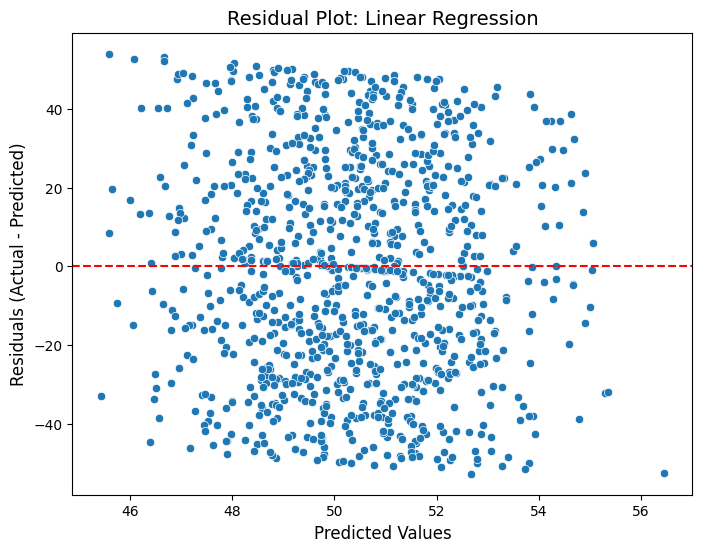

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Calculate residuals
residuals = y_test - lr_pred

plt.figure(figsize=(8,6))

# Scatter plot of predicted vs residuals
sns.scatterplot(
    x=lr_pred,       # Predicted values
    y=residuals       # Residuals (Actual - Predicted)
)

# Add a horizontal line at 0 for reference
plt.axhline(y=0, color='red', linestyle='--')

# Labels and title
plt.title("Residual Plot: Linear Regression", fontsize=14)
plt.xlabel("Predicted Values", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)

plt.show()


9.2 SVR

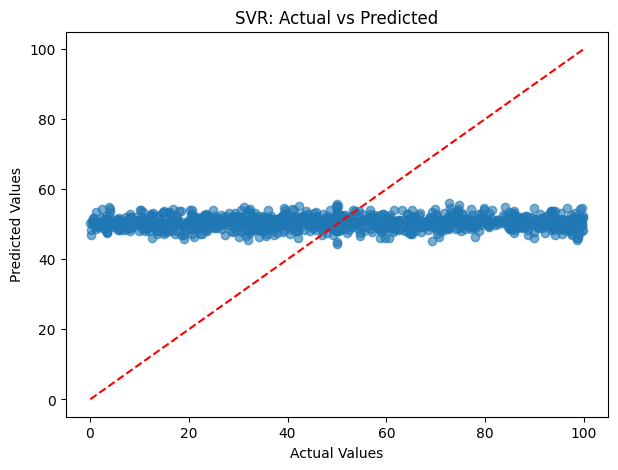

In [ ]:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)

# scatter plot of predicted vs actual

plt.figure(figsize=(7,5))
plt.scatter(y_test, svr_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR: Actual vs Predicted")
plt.show()

9.3 Random Forest Regressor

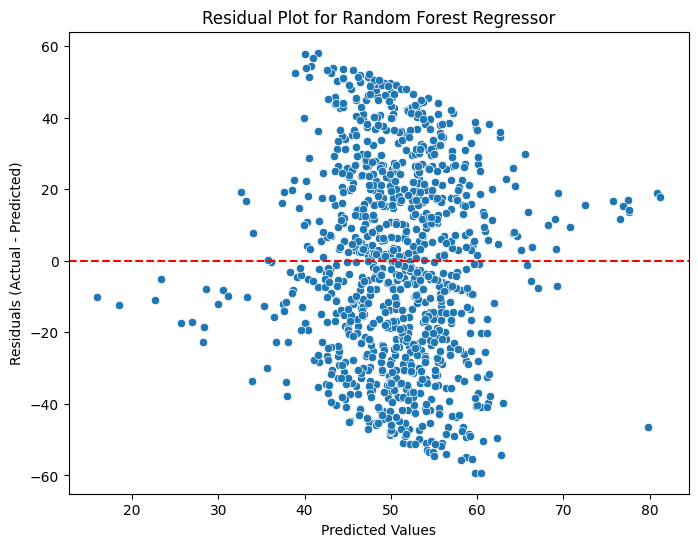

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

#Calculate residuals (Actual - Predicted)
residuals_rf = y_test - rf_pred

# 4. Plot the residuals
plt.figure(figsize=(8,6))
sns.scatterplot(x=rf_pred, y=residuals_rf)
plt.axhline(y=0, color='r', linestyle='--')  # Reference line at 0
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Random Forest Regressor")
plt.show()


9.4 Gradient Boost Regressor

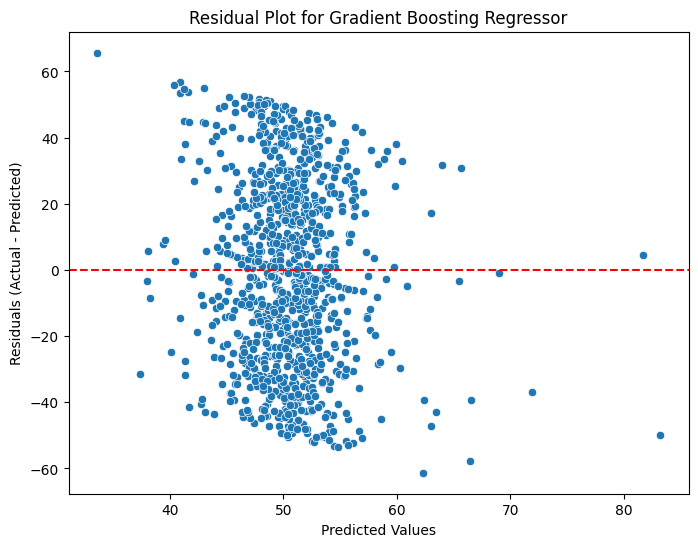

In [ ]:
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr_model.fit(X_train, y_train)
gbr_pred = gbr_model.predict(X_test)

# Calculate residuals
residuals = y_test - gbr_pred

# Plot residuals
plt.figure(figsize=(8,6))
sns.scatterplot(x=gbr_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Gradient Boosting Regressor")
plt.show()


9.5 AdaBoost Regressor

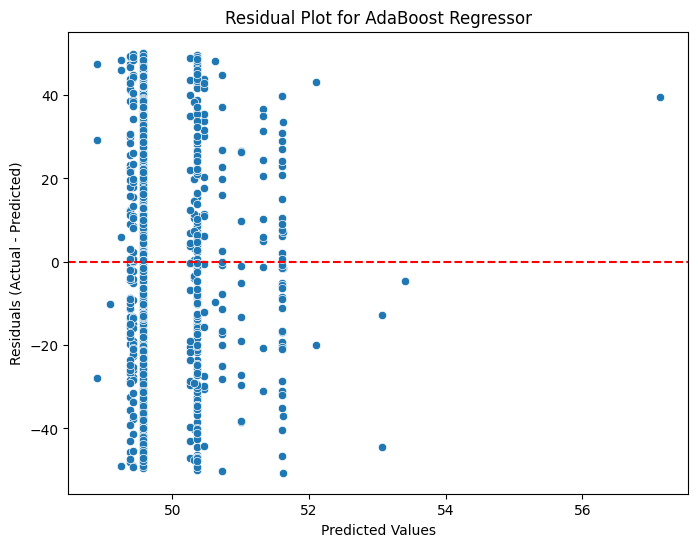

In [ ]:
adb_model = AdaBoostRegressor(n_estimators=100, random_state=42)
adb_model.fit(X_train, y_train)
adb_pred = adb_model.predict(X_test)


#Calculate residuals (Actual - Predicted)
residuals_adb = y_test - adb_pred

# 4. Plot the residuals
plt.figure(figsize=(8,6))
sns.scatterplot(x=adb_pred, y=residuals_adb)
plt.axhline(y=0, color='r', linestyle='--')  # Reference line at 0
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for AdaBoost Regressor")
plt.show()

9.6 MLP Regressor

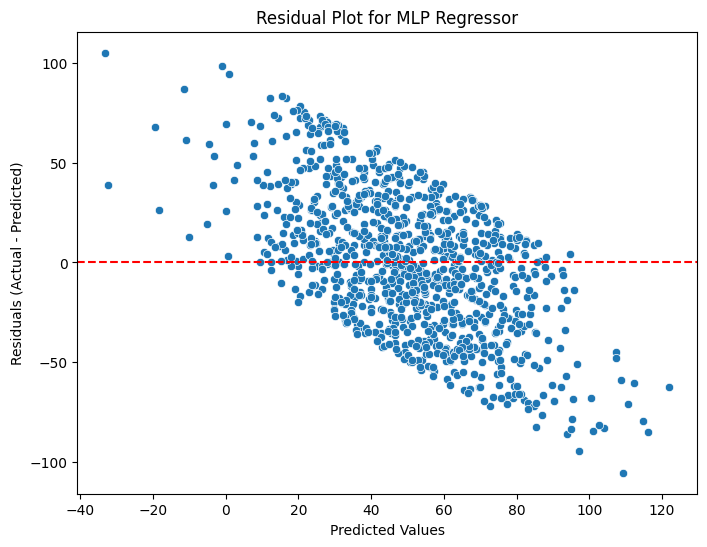

In [ ]:
mlp_model = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

#Calculate residuals (Actual - Predicted)
residuals_mlp = y_test - mlp_pred

# 4. Plot the residuals
plt.figure(figsize=(8,6))
sns.scatterplot(x=mlp_pred, y=residuals_mlp)
plt.axhline(y=0, color='r', linestyle='--')  # Reference line at 0
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for MLP Regressor")
plt.show()

**10. MODEL EVALUATION**

10.1  Evaluating

In [ ]:
def evaluate_model(name, y_true, y_pred):
    """Compute regression metrics: MAE, MSE, RMSE, R²"""

    mae = mean_absolute_error(y_true, y_pred)  # Average absolute difference between prediction and actual
    mse = mean_squared_error(y_true, y_pred)  # Mean squared error
    rmse = np.sqrt(mse)                       # Root mean squared error
    r2 = r2_score(y_true, y_pred)             # R² Score: how much variance is explained

    print(f"\n{name} Metrics:")
    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
    return r2

r2_scores = {}
r2_scores['Linear Regression'] = evaluate_model("Linear Regression", y_test, lr_pred)
r2_scores['SVR'] = evaluate_model("SVR", y_test, svr_pred)
r2_scores['Random Forest'] = evaluate_model("Random Forest", y_test, rf_pred)
r2_scores['Gradient Boost'] = evaluate_model("Gradient Boost", y_test, gbr_pred)
r2_scores['AdaBoost'] = evaluate_model("AdaBoost", y_test, adb_pred)
r2_scores['MLP Regressor'] = evaluate_model("MLP Regressor", y_test, mlp_pred)



Linear Regression Metrics:
MAE: 23.49, MSE: 776.07, RMSE: 27.86, R²: -0.00

SVR Metrics:
MAE: 23.48, MSE: 775.48, RMSE: 27.85, R²: -0.00

Random Forest Metrics:
MAE: 22.72, MSE: 743.59, RMSE: 27.27, R²: 0.04

Gradient Boost Metrics:
MAE: 23.50, MSE: 782.17, RMSE: 27.97, R²: -0.01

AdaBoost Metrics:
MAE: 23.40, MSE: 773.00, RMSE: 27.80, R²: 0.00

MLP Regressor Metrics:
MAE: 27.51, MSE: 1189.21, RMSE: 34.48, R²: -0.54


10.2  Find the model with the maximum R² value

In [ ]:
best_model_name = max(r2_scores, key=r2_scores.get)
best_model_score = r2_scores[best_model_name]

print("🏆 BEST MODEL IDENTIFIED")

print(f"Best Model: {best_model_name}")
print(f"Best R² Score: {best_model_score:.2f}")

🏆 BEST MODEL IDENTIFIED
Best Model: Random Forest
Best R² Score: 0.04


**11. HYPERPARAMETER TUNING**

Linear Regression (Ridge)

In [ ]:
print("\n--- Hyperparameter Tuning: Linear Regression (Ridge) ---")
param_grid_lr = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(Ridge(), param_grid_lr, cv=5, scoring='r2')
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
lr_pred = best_lr.predict(X_test)

print("Best Parameters (Ridge):", grid_lr.best_params_)
print("R² Score:", r2_score(y_test, lr_pred))


--- Hyperparameter Tuning: Linear Regression (Ridge) ---
Best Parameters (Ridge): {'alpha': 100}
R² Score: -0.0028401869948206926


SVR

In [ ]:
print("\n--- Hyperparameter Tuning: SVR (Optimized) ---")

# MUCH SMALLER search space (recommended)
param_grid_svr = {
    'kernel': ['rbf'],                 # rbf performs best 90% of the time
    'C': [1, 10, 50],                  # reduced range
    'gamma': ['scale', 'auto']         # keep simple
}

# Reduce CV folds + use all CPU cores
grid_svr = GridSearchCV(
    SVR(),
    param_grid_svr,
    cv=3,                              # Faster than cv=5
    scoring='r2',
    n_jobs=-1                          # Use all CPU cores ⭐
)

grid_svr.fit(X_train, y_train)

best_svr = grid_svr.best_estimator_
svr_pred = best_svr.predict(X_test)

print("Best Parameters (SVR):", grid_svr.best_params_)
print("R² Score:", r2_score(y_test, svr_pred))




--- Hyperparameter Tuning: SVR (Optimized) ---
Best Parameters (SVR): {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
R² Score: -0.0022217114305205232


Random Forest Regressor

In [ ]:
print("\n--- Hyperparameter Tuning: Random Forest ---")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1       # use all CPU cores
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("R² Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))



--- Hyperparameter Tuning: Random Forest ---
R² Score: 0.027945501336602008
MAE: 22.991486205496248
MSE: 752.1405513142665


Gradient Boost Regressor

In [ ]:
print("\n--- Hyperparameter Tuning: Gradient Boost ---")
gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

gbr_model.fit(X_train, y_train)
gbr_pred = gbr_model.predict(X_test)

print("R² Score:", r2_score(y_test, gbr_pred))
print("MAE:", mean_absolute_error(y_test, gbr_pred))
print("MSE:", mean_squared_error(y_test, gbr_pred))



--- Hyperparameter Tuning: Gradient Boost ---
R² Score: -0.03233163032420605
MAE: 23.666833827565277
MSE: 798.7808118154445


AdaBoost Regressor

In [ ]:
print("\n--- Hyperparameter Tuning: AdaBoost ---")
param_grid_adb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

grid_adb = GridSearchCV(AdaBoostRegressor(random_state=42), param_grid_adb, cv=5, scoring='r2', n_jobs=-1)
grid_adb.fit(X_train, y_train)

best_adb = grid_adb.best_estimator_
adb_pred = best_adb.predict(X_test)

print("Best Parameters (AdaBoost):", grid_adb.best_params_)
print("R² Score:", r2_score(y_test, adb_pred))





--- Hyperparameter Tuning: AdaBoost ---
Best Parameters (AdaBoost): {'learning_rate': 0.01, 'n_estimators': 200}
R² Score: -0.0014292978274508261


MLP Regressor

In [ ]:
print("\n--- Hyperparameter Tuning: MLP Regressor ---")
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=1500,
    random_state=42
)

mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

print("R² Score:", r2_score(y_test, mlp_pred))
print("MAE:", mean_absolute_error(y_test, mlp_pred))
print("MSE:", mean_squared_error(y_test, mlp_pred))




--- Hyperparameter Tuning: MLP Regressor ---
R² Score: -0.745524692025143
MAE: 29.743697269430417
MSE: 1350.6237623484105


In [ ]:
# Collect predictions from each model
# ----------------------------------------
model_predictions = {
    "Linear Regression": lr_pred,
    "SVR (Best)": svr_pred,
    "Random Forest (Best)": rf_pred,
    "Gradient Boosting (Best)": gbr_pred,
    "MLP Regressor (Best)": mlp_pred
}

# ----------------------------------------
# Evaluation storage
# ----------------------------------------
evaluation_results = {
    "Model": [],
    "R2 Score": [],
    "MAE": [],
    "MSE": [],
    "RMSE": []
}

# ----------------------------------------
# Compute all metrics for each model
# ----------------------------------------
for model_name, pred in model_predictions.items():
    evaluation_results["Model"].append(model_name)
    evaluation_results["R2 Score"].append(r2_score(y_test, pred))
    evaluation_results["MAE"].append(mean_absolute_error(y_test, pred))
    evaluation_results["MSE"].append(mean_squared_error(y_test, pred))
    evaluation_results["RMSE"].append(np.sqrt(mean_squared_error(y_test, pred)))

# ----------------------------------------
# Convert to DataFrame for better display
# ----------------------------------------
eval_df = pd.DataFrame(evaluation_results)

print("\n================ MODEL PERFORMANCE COMPARISON ================\n")
print(eval_df)

# Sort by highest R2 (best performance)
print("\n================ MODELS SORTED BY PERFORMANCE (R2 DESC) ================\n")
print(eval_df.sort_values(by="R2 Score", ascending=False))


================ MODEL PERFORMANCE COMPARISON ================

                      Model  R2 Score        MAE          MSE       RMSE
0         Linear Regression -0.002840  23.489479   775.961402  27.856084
1                SVR (Best) -0.002222  23.482541   775.482848  27.847493
2      Random Forest (Best)  0.027946  22.991486   752.140551  27.425181
3  Gradient Boosting (Best) -0.032332  23.666834   798.780812  28.262711
4      MLP Regressor (Best) -0.745525  29.743697  1350.623762  36.750833

================ MODELS SORTED BY PERFORMANCE (R2 DESC) ================

                      Model  R2 Score        MAE          MSE       RMSE
2      Random Forest (Best)  0.027946  22.991486   752.140551  27.425181
1                SVR (Best) -0.002222  23.482541   775.482848  27.847493
0         Linear Regression -0.002840  23.489479   775.961402  27.856084
3  Gradient Boosting (Best) -0.032332  23.666834   798.780812  28.262711
4      MLP Regressor (Best) -0.745525  29.743697  1350.62

**12. Save the model**

In [ ]:
import joblib

# Save model for future predictions
joblib.dump(rf_model, "athlete_performance_model.pkl")
# Save scaler to preprocess new data consistently

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

**13.  Test with UNSEEN DATA**

In [ ]:
import joblib # Import joblib for loading models and scalers

# Load the best model and scaler
loaded_model = joblib.load("athlete_performance_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Use the row directly with feature names
new_data = X.iloc[[0]]   # double brackets keep DataFrame format

# Scale it using the loaded scaler
new_data_scaled = loaded_scaler.transform(new_data)

# Predict using the loaded best model
prediction = loaded_model.predict(new_data_scaled)

print("Predicted Performance_Metric:", prediction[0])

Predicted Performance_Metric: 64.38893477373966


**Conclusion**


- Performance: All models show very low R² (~0) → minimal predictive power.

- Best model: Random Forest slightly better, but still unreliable.

- Errors: MAE ~22–26, RMSE ~27–32 → predictions far from actual values.

- Limitations:

- Small dataset & missing important features (training history, nutrition, physiology).

- High noise or low correlation between features and target.
